# **LIMPEZA DO DATASET ECOLI**

## **Características do Dataset**

In [86]:
# Verificação dos tipos de dados
import numpy as np
import pandas as pd

dataset = pd.read_csv("Ecoli2.csv", encoding='utf-8')

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mcg     336 non-null    float64
 1   gvh     335 non-null    float64
 2   lip     335 non-null    float64
 3   chg     336 non-null    float64
 4   aac     332 non-null    float64
 5   alm1    336 non-null    float64
 6   alm2    336 non-null    float64
 7   class   332 non-null    object 
dtypes: float64(7), object(1)
memory usage: 21.1+ KB


## **Mostragem de 10 registros**

In [87]:
dataset.head(10)

,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,0.07,0.40,0.48,0.5,0.54,0.35,0.44,NaN
2,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,0.59,0.49,0.48,0.5,0.52,0.45,0.36,NaN
4,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp
5,0.67,0.39,0.48,0.5,0.36,0.38,0.46,NaN
6,0.29,0.28,0.48,0.5,0.44,0.23,0.34,NaN
7,0.21,0.34,0.48,0.5,0.51,0.28,0.39,cp
8,0.20,0.44,0.48,0.5,0.46,0.51,0.57,cp
9,0.42,0.40,0.48,0.5,NaN,0.18,0.30,cp


## **Checagem de Missing Values**

In [88]:
missing = dataset.isnull().sum()
print(missing)

mcg      0
gvh      1
lip      1
chg      0
aac      4
alm1     0
alm2     0
class    4
dtype: int64


## **Substituindo os Missing Values numéricos pela Mediana**

In [89]:
dataset3 = dataset

dataset3['gvh'] = dataset3['gvh'].fillna(dataset3['gvh'].median())
dataset3['lip'] = dataset3['lip'].fillna(dataset3['lip'].median())
dataset3['aac'] = dataset3['aac'].fillna(dataset3['aac'].median())

# Verificação dos Missing Values novamente
print(dataset3.isnull().sum())

mcg      0
gvh      0
lip      0
chg      0
aac      0
alm1     0
alm2     0
class    4
dtype: int64


## **Substituindo os Missing Values categóricos pela Moda**

In [90]:
# Suavizando missing values
dataset3['class'].fillna(dataset3['class'].mode()[0], inplace=True)

# Verificação dos Missing Values
print(dataset3.isnull().sum())

mcg      0
gvh      0
lip      0
chg      0
aac      0
alm1     0
alm2     0
class    0
dtype: int64


/tmp/ipykernel_401/3974450353.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset3['class'].fillna(dataset3['class'].mode()[0], inplace=True)


## **Mostragem dos 10 registros corrigidos**

In [91]:
dataset3.head(10)

,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,0.49,0.29,0.48,0.5,0.560,0.24,0.35,cp
1,0.07,0.40,0.48,0.5,0.540,0.35,0.44,cp
2,0.56,0.40,0.48,0.5,0.490,0.37,0.46,cp
3,0.59,0.49,0.48,0.5,0.520,0.45,0.36,cp
4,0.23,0.32,0.48,0.5,0.550,0.25,0.35,cp
5,0.67,0.39,0.48,0.5,0.360,0.38,0.46,cp
6,0.29,0.28,0.48,0.5,0.440,0.23,0.34,cp
7,0.21,0.34,0.48,0.5,0.510,0.28,0.39,cp
8,0.20,0.44,0.48,0.5,0.460,0.51,0.57,cp
9,0.42,0.40,0.48,0.5,0.495,0.18,0.30,cp


## **Detecção de outliers**

<Axes: >

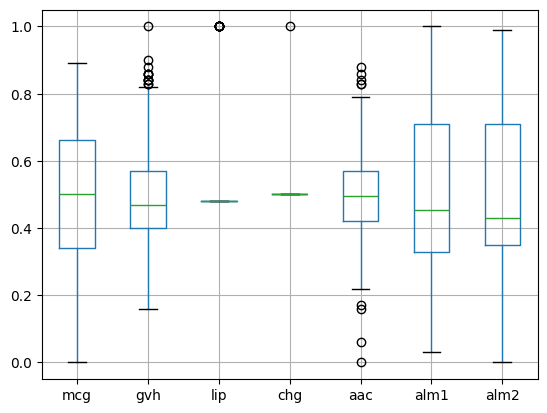

In [92]:
import matplotlib.pyplot as plt

atributos = ['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']
dados = dataset3[atributos]

dataset3.boxplot(column=atributos)

## **Aplicando intervalo interquartil para limpeza dos outliers**

<Axes: >

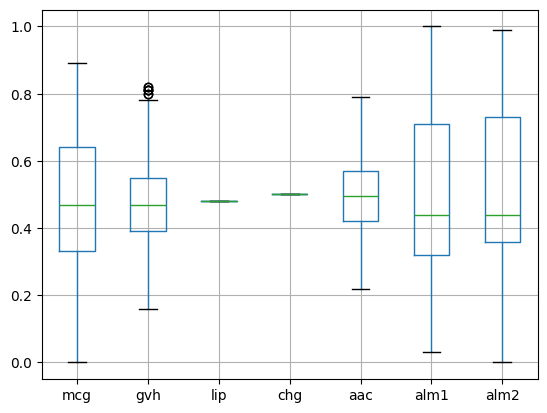

In [93]:
n = len(dataset3)

# Calculando as posições
posicao_q1 = (n+1)/4
posicao_q3 = (3*(n+1))/4

# Ajustando a posição para número interiro e subtraindo 1 por conta do índice
idx_q1 = int(posicao_q1)-1
idx_q3 = int(posicao_q3)-1

limites = {}

# Fazendo a conta para cada um dos atributos
for col in atributos:
  valores_ordenados = dataset3[col].sort_values().values
  q1 = valores_ordenados[idx_q1]
  q3 = valores_ordenados[idx_q3]

  inter = q3-q1 # fórmula do intervalo

  inferior = q1 - (1.5*inter)
  superior = q3 + (1.5*inter)

  limites[col] = [inferior, superior]

# Limpeza
dataset4 = dataset3.copy()

for col in atributos:
  inf, sup = limites[col]
  dataset4 = dataset4[(dataset4[col] >= inf) & (dataset4[col] <= sup)]

# Verificação de outliers pós limpeza
dataset4.boxplot(column=atributos)

In [65]:
# Baixar o dataset com limpeza, mas sem binarização para usar na amostragem estratificada

dataset4.to_csv('dataset_sem_binarizacao.csv', index=False)

print("Arquivo salvo")

Arquivo salvo


## **Transformação de categóricos para binários**

In [94]:
tipos_categoricos = ['object']
cols_cat = dataset4.select_dtypes(include=tipos_categoricos)

# Binarizando os atributos
categoricoToBinary = pd.get_dummies(cols_cat, dtype = int)
dados_binarios = dataset4.join(categoricoToBinary)

dados_binarios.drop(cols_cat.columns.to_list(), axis=1, inplace=True)

#Visualização
dados_binarios.head()

,mcg,gvh,lip,chg,aac,alm1,alm2,class_cp,class_im,class_imS,class_imU,class_om,class_pp
0,0.49,0.29,0.48,0.5,0.56,0.24,0.35,1,0,0,0,0,0
1,0.07,0.40,0.48,0.5,0.54,0.35,0.44,1,0,0,0,0,0
2,0.56,0.40,0.48,0.5,0.49,0.37,0.46,1,0,0,0,0,0
3,0.59,0.49,0.48,0.5,0.52,0.45,0.36,1,0,0,0,0,0
4,0.23,0.32,0.48,0.5,0.55,0.25,0.35,1,0,0,0,0,0


In [67]:
dados_binarios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306 entries, 0 to 335
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mcg        306 non-null    float64
 1   gvh        306 non-null    float64
 2   lip        306 non-null    float64
 3   chg        306 non-null    float64
 4   aac        306 non-null    float64
 5   alm1       306 non-null    float64
 6   alm2       306 non-null    float64
 7   class_cp   306 non-null    int64  
 8   class_im   306 non-null    int64  
 9   class_imS  306 non-null    int64  
 10  class_imU  306 non-null    int64  
 11  class_om   306 non-null    int64  
 12  class_pp   306 non-null    int64  
dtypes: float64(7), int64(6)
memory usage: 33.5 KB


## **Salvar a versão limpa em csv**

In [68]:
dados_binarios.to_csv('dataset_limpo.csv', index=False)

print("Arquivo salvo")

Arquivo salvo


# **Amostragem de Dados**

In [79]:
dataset_novo = pd.read_csv('dataset_limpo.csv', encoding='utf-8')

dataset_novo.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mcg        306 non-null    float64
 1   gvh        306 non-null    float64
 2   lip        306 non-null    float64
 3   chg        306 non-null    float64
 4   aac        306 non-null    float64
 5   alm1       306 non-null    float64
 6   alm2       306 non-null    float64
 7   class_cp   306 non-null    int64  
 8   class_im   306 non-null    int64  
 9   class_imS  306 non-null    int64  
 10  class_imU  306 non-null    int64  
 11  class_om   306 non-null    int64  
 12  class_pp   306 non-null    int64  
dtypes: float64(7), int64(6)
memory usage: 31.2 KB


## 1. Amostragem simples de 30% e sem reposição

In [80]:
amostra_1 = dataset_novo.sample(frac=0.3, replace=False, random_state=2)
print(amostra_1)

      mcg   gvh   lip  chg   aac  alm1  alm2  class_cp  class_im  class_imS  \
273  0.67  0.81  0.48  0.5  0.25  0.42  0.25         0         0          0   
166  0.47  0.59  0.48  0.5  0.52  0.76  0.79         0         1          0   
106  0.43  0.32  0.48  0.5  0.33  0.45  0.52         1         0          0   
30   0.53  0.38  0.48  0.5  0.44  0.26  0.36         1         0          0   
77   0.41  0.48  0.48  0.5  0.51  0.44  0.51         1         0          0   
..    ...   ...   ...  ...   ...   ...   ...       ...       ...        ...   
20   0.40  0.45  0.48  0.5  0.38  0.22  0.00         1         0          0   
28   0.43  0.37  0.48  0.5  0.53  0.35  0.44         1         0          0   
235  0.63  0.42  0.48  0.5  0.48  0.77  0.80         0         0          0   
120  0.24  0.41  0.48  0.5  0.49  0.23  0.34         1         0          0   
71   0.44  0.51  0.48  0.5  0.47  0.26  0.36         1         0          0   

     class_imU  class_om  class_pp  
273          0

## 2. Amostragem simples de 30% e com reposição

In [81]:
amostra_2 = dataset_novo.sample(frac=0.3, replace=True, random_state=2)
print(amostra_2)

      mcg   gvh   lip  chg   aac  alm1  alm2  class_cp  class_im  class_imS  \
168  0.49  0.42  0.48  0.5  0.53  0.79  0.81         0         1          0   
15   0.25  0.40  0.48  0.5  0.46  0.44  0.52         1         0          0   
72   0.37  0.50  0.48  0.5  0.42  0.36  0.45         1         0          0   
22   0.51  0.54  0.48  0.5  0.41  0.34  0.43         1         0          0   
299  0.69  0.65  0.48  0.5  0.63  0.48  0.41         0         0          0   
..    ...   ...   ...  ...   ...   ...   ...       ...       ...        ...   
187  0.61  0.52  0.48  0.5  0.54  0.67  0.52         0         1          0   
177  0.83  0.37  0.48  0.5  0.61  0.71  0.74         0         1          0   
250  0.79  0.54  0.48  0.5  0.50  0.66  0.68         0         0          0   
255  0.56  0.68  0.48  0.5  0.77  0.36  0.45         0         0          0   
27   0.21  0.47  0.48  0.5  0.50  0.32  0.41         1         0          0   

     class_imU  class_om  class_pp  
168          0

## 3. Amostragem simples de 50% e sem reposição

In [82]:
amostra_3 = dataset_novo.sample(frac=0.5, replace=False, random_state=2)
print(amostra_3)

      mcg   gvh   lip  chg   aac  alm1  alm2  class_cp  class_im  class_imS  \
273  0.67  0.81  0.48  0.5  0.25  0.42  0.25         0         0          0   
166  0.47  0.59  0.48  0.5  0.52  0.76  0.79         0         1          0   
106  0.43  0.32  0.48  0.5  0.33  0.45  0.52         1         0          0   
30   0.53  0.38  0.48  0.5  0.44  0.26  0.36         1         0          0   
77   0.41  0.48  0.48  0.5  0.51  0.44  0.51         1         0          0   
..    ...   ...   ...  ...   ...   ...   ...       ...       ...        ...   
42   0.40  0.50  0.48  0.5  0.45  0.39  0.47         1         0          0   
261  0.71  0.71  0.48  0.5  0.68  0.43  0.36         0         0          0   
57   0.40  0.35  0.48  0.5  0.45  0.33  0.42         1         0          0   
145  0.23  0.48  0.48  0.5  0.59  0.88  0.89         0         1          0   
122  0.04  0.31  0.48  0.5  0.41  0.29  0.39         1         0          0   

     class_imU  class_om  class_pp  
273          0

## 4. Amostragem simples de 50% e com reposição

In [83]:
amostra_4 = dataset_novo.sample(frac=0.5, replace=True, random_state=2)
print(amostra_4)

      mcg   gvh   lip  chg    aac  alm1  alm2  class_cp  class_im  class_imS  \
168  0.49  0.42  0.48  0.5  0.530  0.79  0.81         0         1          0   
15   0.25  0.40  0.48  0.5  0.460  0.44  0.52         1         0          0   
72   0.37  0.50  0.48  0.5  0.420  0.36  0.45         1         0          0   
22   0.51  0.54  0.48  0.5  0.410  0.34  0.43         1         0          0   
299  0.69  0.65  0.48  0.5  0.630  0.48  0.41         0         0          0   
..    ...   ...   ...  ...    ...   ...   ...       ...       ...        ...   
296  0.29  0.39  0.48  0.5  0.520  0.40  0.48         0         0          0   
19   0.41  0.57  0.48  0.5  0.495  0.21  0.32         1         0          0   
184  0.89  0.55  0.48  0.5  0.510  0.72  0.76         0         1          0   
206  0.31  0.36  0.48  0.5  0.580  0.94  0.94         0         1          0   
49   0.23  0.33  0.48  0.5  0.430  0.33  0.43         1         0          0   

     class_imU  class_om  class_pp  
16

## 5. Amostragem estratificada de 50% (mesmas proporções)

In [74]:
# Leitura do dataset sem binarização
df_sem_bin = pd.read_csv('dataset_sem_binarizacao.csv', encoding='utf-8')

df_sem_bin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mcg     306 non-null    float64
 1   gvh     306 non-null    float64
 2   lip     306 non-null    float64
 3   chg     306 non-null    float64
 4   aac     306 non-null    float64
 5   alm1    306 non-null    float64
 6   alm2    306 non-null    float64
 7   class   306 non-null    object 
dtypes: float64(7), object(1)
memory usage: 19.3+ KB


In [75]:
# Amostragem estratificada de 50%
classes = df_sem_bin['class'].unique()

tamanho_50 = round(len(df_sem_bin)*0.5) # 168 linhas
qtde_por_classe_50 = round(tamanho_50/len(classes)) # 168/6 = 28 por classe

amostra5 = []
for classe in classes:
  selecao = df_sem_bin.loc[df_sem_bin['class'] == classe]

  if len(selecao) < qtde_por_classe_50:
    amostra_c = selecao.sample(n=qtde_por_classe_50, replace=True, random_state=2)

  else:
    amostra_c = selecao.sample(n=qtde_por_classe_50, replace=False, random_state=2)

amostra5.append(amostra_c)

amostra_estratificada_5 = pd.concat(amostra5)
print(amostra_estratificada_5)

      mcg   gvh   lip  chg   aac  alm1  alm2 class
290  0.69  0.59  0.48  0.5  0.46  0.44  0.52    pp
272  0.66  0.74  0.48  0.5  0.31  0.38  0.43    pp
277  0.70  0.64  0.48  0.5  0.47  0.51  0.47    pp
263  0.74  0.49  0.48  0.5  0.42  0.54  0.36    pp
265  0.73  0.78  0.48  0.5  0.58  0.51  0.31    pp
298  0.69  0.66  0.48  0.5  0.41  0.50  0.25    pp
276  0.32  0.39  0.48  0.5  0.53  0.28  0.38    pp
301  0.74  0.56  0.48  0.5  0.47  0.68  0.30    pp
280  0.63  0.71  0.48  0.5  0.60  0.40  0.39    pp
302  0.71  0.57  0.48  0.5  0.48  0.35  0.32    pp
305  0.74  0.74  0.48  0.5  0.31  0.53  0.52    pp
293  0.62  0.78  0.48  0.5  0.47  0.49  0.54    pp
287  0.64  0.66  0.48  0.5  0.41  0.39  0.20    pp
275  0.68  0.82  0.48  0.5  0.38  0.65  0.56    pp
279  0.74  0.82  0.48  0.5  0.49  0.49  0.41    pp
264  0.70  0.61  0.48  0.5  0.56  0.52  0.43    pp
295  0.64  0.81  0.48  0.5  0.37  0.39  0.44    pp
286  0.69  0.80  0.48  0.5  0.46  0.57  0.26    pp
288  0.63  0.80  0.48  0.5  0.4

## 6. Amostragem simples de 70% e sem reposição

In [84]:
amostra_6 = dataset_novo.sample(frac=0.70, replace=False, random_state=2)
print(amostra_6)

      mcg   gvh   lip  chg   aac  alm1  alm2  class_cp  class_im  class_imS  \
273  0.67  0.81  0.48  0.5  0.25  0.42  0.25         0         0          0   
166  0.47  0.59  0.48  0.5  0.52  0.76  0.79         0         1          0   
106  0.43  0.32  0.48  0.5  0.33  0.45  0.52         1         0          0   
30   0.53  0.38  0.48  0.5  0.44  0.26  0.36         1         0          0   
77   0.41  0.48  0.48  0.5  0.51  0.44  0.51         1         0          0   
..    ...   ...   ...  ...   ...   ...   ...       ...       ...        ...   
143  0.44  0.52  0.48  0.5  0.43  0.47  0.54         0         1          0   
17   0.44  0.27  0.48  0.5  0.55  0.52  0.58         1         0          0   
59   0.42  0.38  0.48  0.5  0.54  0.34  0.43         1         0          0   
165  0.54  0.57  0.48  0.5  0.56  0.81  0.83         0         1          0   
225  0.75  0.37  0.48  0.5  0.64  0.70  0.74         0         0          0   

     class_imU  class_om  class_pp  
273          0

## 7. Amostragem simples de 70% e com reposição

In [85]:
amostra_7 = dataset_novo.sample(frac=0.70, replace=True, random_state=2)
print(amostra_7)

      mcg   gvh   lip  chg   aac  alm1  alm2  class_cp  class_im  class_imS  \
168  0.49  0.42  0.48  0.5  0.53  0.79  0.81         0         1          0   
15   0.25  0.40  0.48  0.5  0.46  0.44  0.52         1         0          0   
72   0.37  0.50  0.48  0.5  0.42  0.36  0.45         1         0          0   
22   0.51  0.54  0.48  0.5  0.41  0.34  0.43         1         0          0   
299  0.69  0.65  0.48  0.5  0.63  0.48  0.41         0         0          0   
..    ...   ...   ...  ...   ...   ...   ...       ...       ...        ...   
92   0.30  0.45  0.48  0.5  0.36  0.21  0.32         1         0          0   
91   0.41  0.43  0.48  0.5  0.50  0.24  0.25         1         0          0   
243  0.64  0.45  0.48  0.5  0.67  0.61  0.66         0         0          0   
74   0.24  0.43  0.48  0.5  0.37  0.28  0.38         1         0          0   
282  0.74  0.47  0.48  0.5  0.50  0.57  0.42         0         0          0   

     class_imU  class_om  class_pp  
168          0

## 8. Amostragem estratificada de 70% (mesmas proporções)

In [78]:
tamanho_70 = round(len(df_sem_bin) * 0.70)
qtde_por_classe_70 = round(tamanho_70 / len(classes))

amostra8 = []
for classe in classes:
    selecao = df_sem_bin.loc[df_sem_bin['class'] == classe]

    if len(selecao) < qtde_por_classe_70:
        amostra_c = selecao.sample(n=qtde_por_classe_70, replace=True, random_state=2)
    else:
        amostra_c = selecao.sample(n=qtde_por_classe_70, replace=False,random_state=2)

    amostra8.append(amostra_c)

amostra_estratificada_8 = pd.concat(amostra8)
print(amostra_estratificada_8)

      mcg   gvh   lip  chg   aac  alm1  alm2 class
132  0.27  0.30  0.48  0.5  0.71  0.28  0.39    cp
100  0.24  0.57  0.48  0.5  0.63  0.34  0.43    cp
94   0.64  0.76  0.48  0.5  0.45  0.35  0.38    cp
41   0.30  0.37  0.48  0.5  0.59  0.41  0.49    cp
3    0.59  0.49  0.48  0.5  0.52  0.45  0.36    cp
..    ...   ...   ...  ...   ...   ...   ...   ...
304  0.59  0.61  0.48  0.5  0.42  0.42  0.37    pp
284  0.69  0.67  0.48  0.5  0.30  0.39  0.24    pp
300  0.43  0.59  0.48  0.5  0.52  0.49  0.56    pp
294  0.76  0.73  0.48  0.5  0.44  0.39  0.39    pp
297  0.56  0.54  0.48  0.5  0.43  0.37  0.30    pp

[216 rows x 8 columns]
